# Q1 The Income Trap

Question 1

The capital-gain column is not just an outlier issue, it is mainly a distribution problem.

Most of the values are zero, and only a few values are very large. So the data is highly right-skewed and not normal.

In a normal distribution, values are more balanced around the mean and extreme values are rare. But here, we have a big pile of zeros and a long tail of large values. So it breaks the normal distribution assumption.

That’s why it is more than just outliers, it is a skewed, zero-inflated distribution.

Question 2

If we apply StandardScaler (Z-score), the extreme values will get very large Z-scores because mean and standard deviation get affected by those huge values.

So outliers will dominate the scaling.

RobustScaler is better here because it uses median and IQR instead of mean and std. So it is not heavily affected by extreme values.

So basically RobustScaler gives more stable scaling for this type of data.

Question 3

Winsorization means we cut off extreme values at some percentile limit. For example 5% and 95%.

So values below 5th percentile become same as 5th percentile, and above 95th become same as 95th percentile.

This assumes that extreme values are not very important or maybe noise.

But risk is we can lose real information, especially in income data where high values may actually be meaningful.

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
5514,33,Local-gov,198183,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,50,United-States,>50K
19777,36,Private,86459,Assoc-voc,11,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1887,50,United-States,>50K
10781,58,Self-emp-not-inc,203039,9th,5,Separated,Craft-repair,Not-in-family,White,Male,0,0,40,United-States,<=50K
32240,21,Private,180190,Assoc-voc,11,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,46,United-States,<=50K
9876,27,Private,279872,Some-college,10,Divorced,Other-service,Not-in-family,White,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,47,Private,359461,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
5390,31,Private,147215,12th,8,Divorced,Other-service,Unmarried,White,Female,0,0,21,United-States,<=50K
860,18,Private,216284,11th,7,Never-married,Adm-clerical,Own-child,White,Female,0,0,20,United-States,<=50K
15795,50,Self-emp-not-inc,54261,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,84,United-States,<=50K


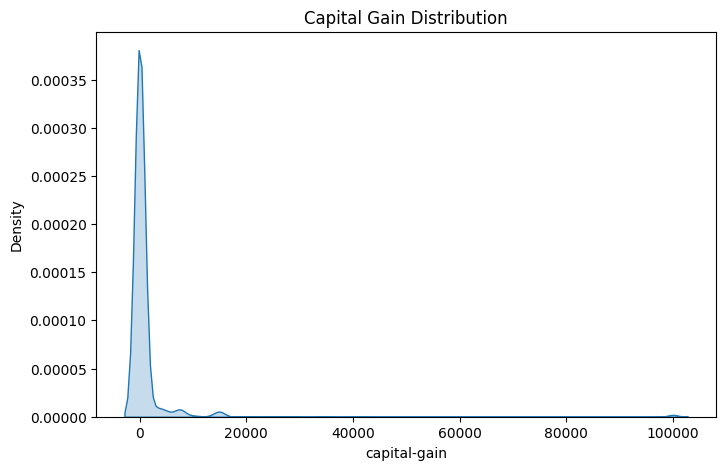

In [1]:


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


cols = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
       "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]
df = pd.read_csv("F:/Jupyter_Projects/Phitron AL ML/Dataset/adult.txt", names = cols)
df = df.replace("?", pd.NA)

df = df.dropna()


train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

display(train_df)

plt.figure(figsize=(8,5))
sns.kdeplot(train_df["capital-gain"], fill=True)
plt.title("Capital Gain Distribution")
plt.show()

Question 5

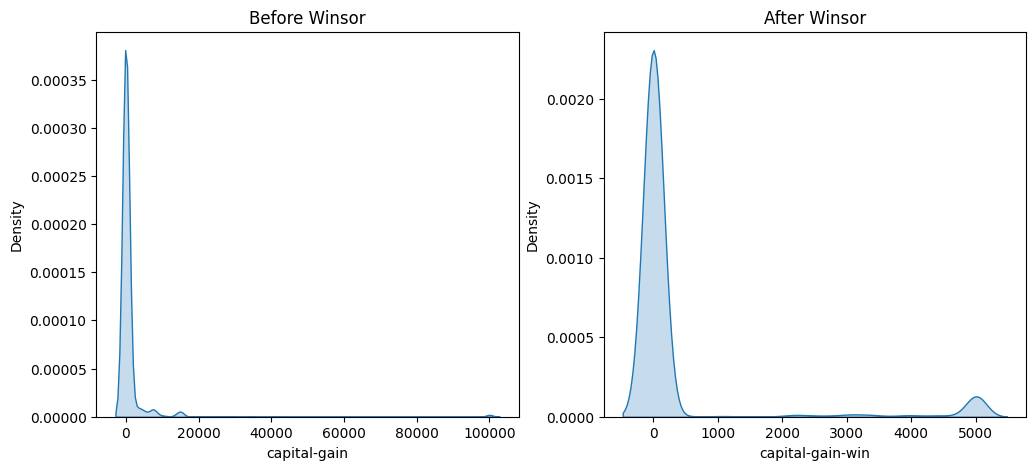

In [2]:
lower = train_df["capital-gain"].quantile(0.05)
upper = train_df["capital-gain"].quantile(0.95)

train_df["capital-gain-win"] = train_df["capital-gain"].clip(lower, upper)
test_df["capital-gain-win"] = test_df["capital-gain"].clip(lower, upper)


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.kdeplot(train_df["capital-gain"], fill=True)
plt.title("Before Winsor")

plt.subplot(1,2,2)
sns.kdeplot(train_df["capital-gain-win"], fill=True)
plt.title("After Winsor")

plt.show()

Question 6

In [3]:
from sklearn.preprocessing import StandardScaler, RobustScaler

cols = ["hours-per-week", "capital-gain"]


std = StandardScaler()
std_scaled = std.fit_transform(train_df[cols])


rob = RobustScaler()
rob_scaled = rob.fit_transform(train_df[cols])

print("StandardScaler range:")
print(std_scaled.min(axis=0), std_scaled.max(axis=0))

print("RobustScaler range:")
print(rob_scaled.min(axis=0), rob_scaled.max(axis=0))

StandardScaler range:
[-3.19429597 -0.14571521] [ 4.75321644 13.68413909]
RobustScaler range:
[-7.8  0. ] [1.1800e+01 9.9999e+04]


# Q2 The Churning Machine

Question 7:

The target column Churn is imbalanced because around 73% of customers are labeled as No and only 27% are labeled as Yes. This matters because the model may become biased toward the majority class. If the imbalance is not handled properly, the model might predict most customers as No to achieve high accuracy, while failing to correctly identify customers who are likely to leave the company.


Question 8:

In TotalCharges column there are some 0, which indicates that the customers are new and have not been charged yet. In those rows, the column may contain blank spaces instead of numeric values, that's why the entire column treated as object.

Question 9:

A countplot with hue shows the number of frequency or observations in each category and separates them by another categorical variable using different colors.

A grouped bar chart shows the average value of a numerical variable for different categories. It is used to compare statistical values like mean, median, sum between groups.

Question 10:

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [5]:
df_churn = pd.read_csv("F:/Jupyter_Projects/Phitron AL ML/Dataset/churn.csv")
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df_churn.TotalCharges.dtype

dtype('O')

In [7]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df_churn.TotalCharges = df_churn.TotalCharges.replace(" ",np.nan)
df_churn.TotalCharges = df_churn.TotalCharges.astype(float)

In [9]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df_churn.OnlineSecurity.value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Question 11:

gender
Male      3555
Female    3488
Name: count, dtype: int64

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

...

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

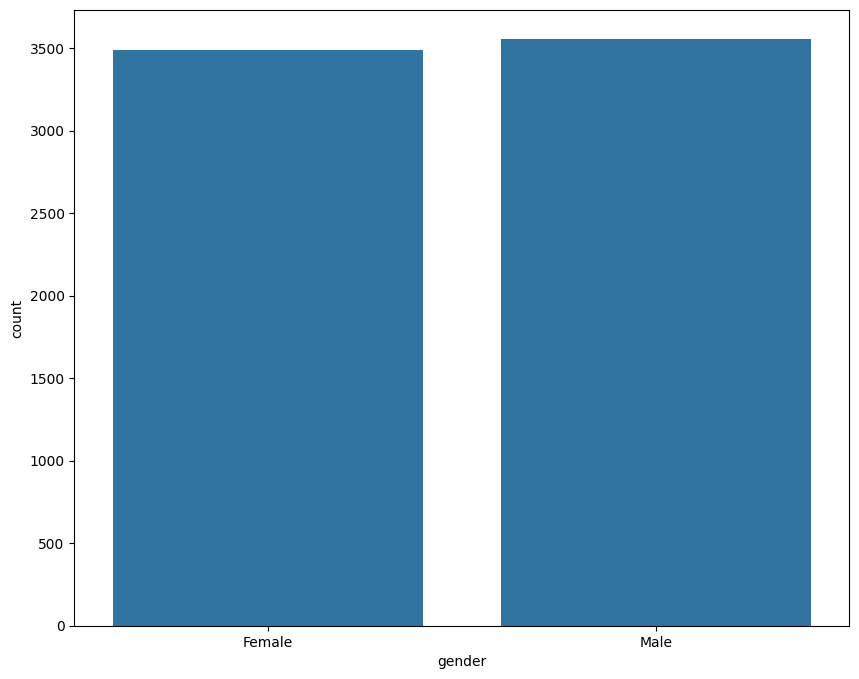

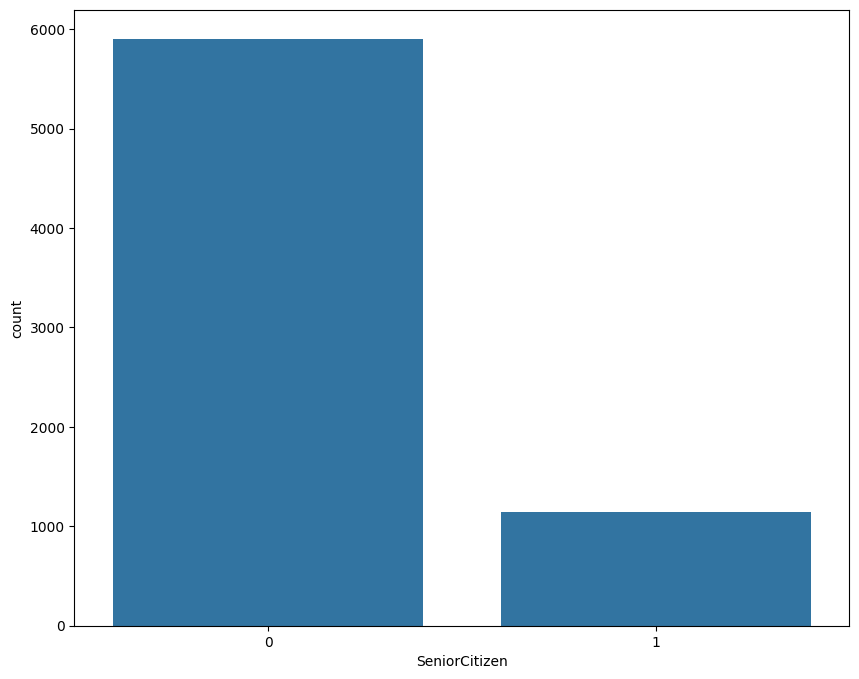

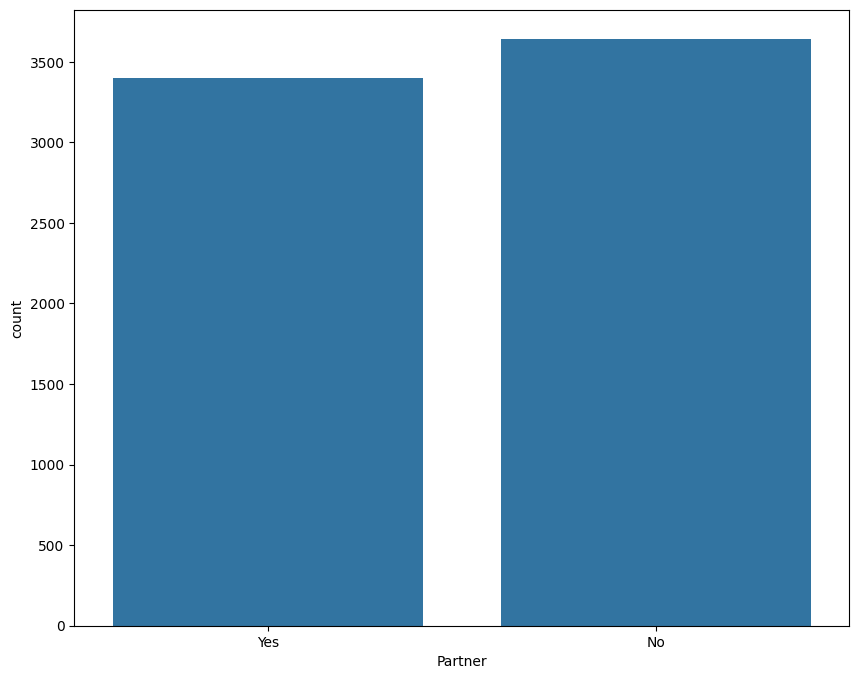

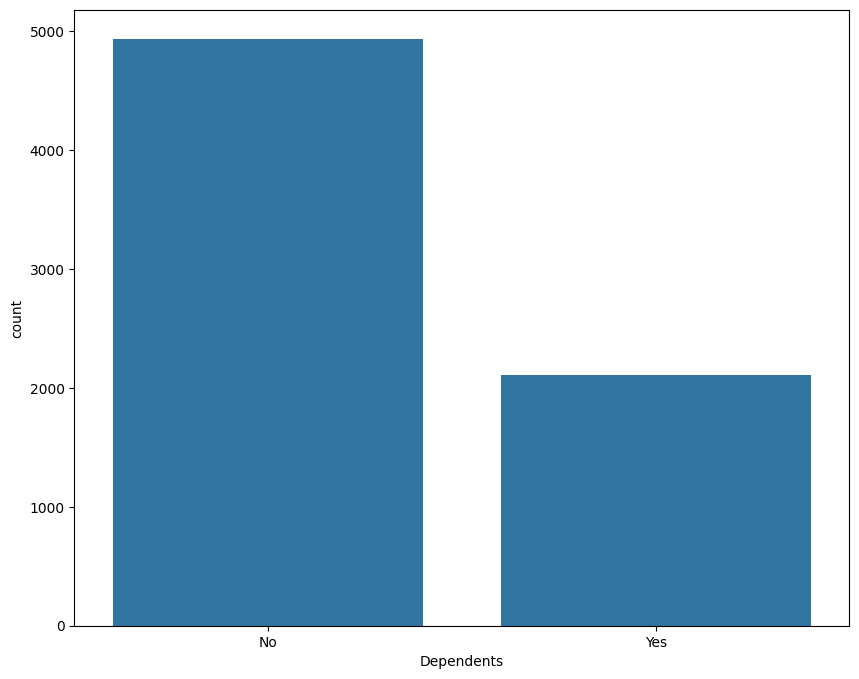

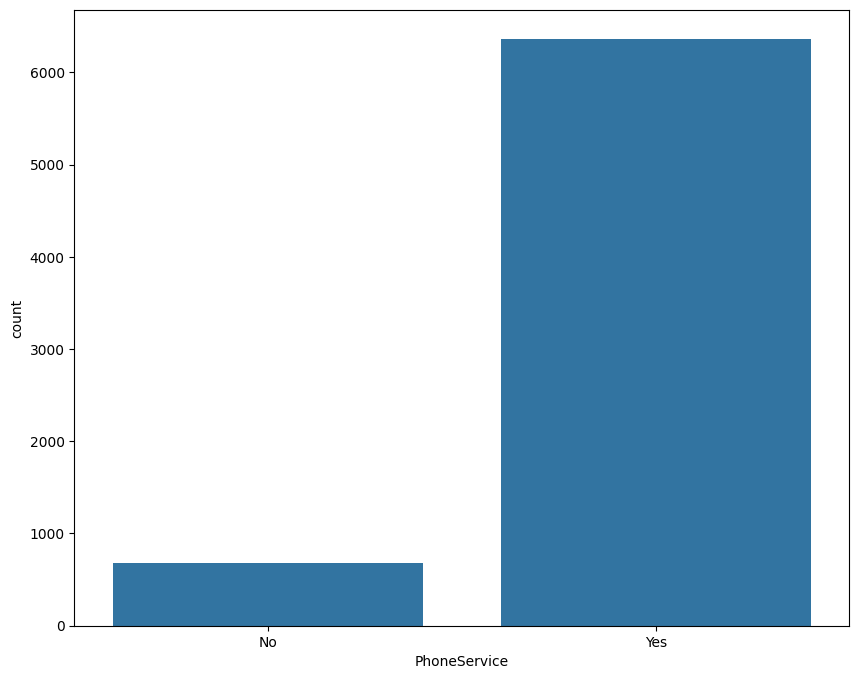

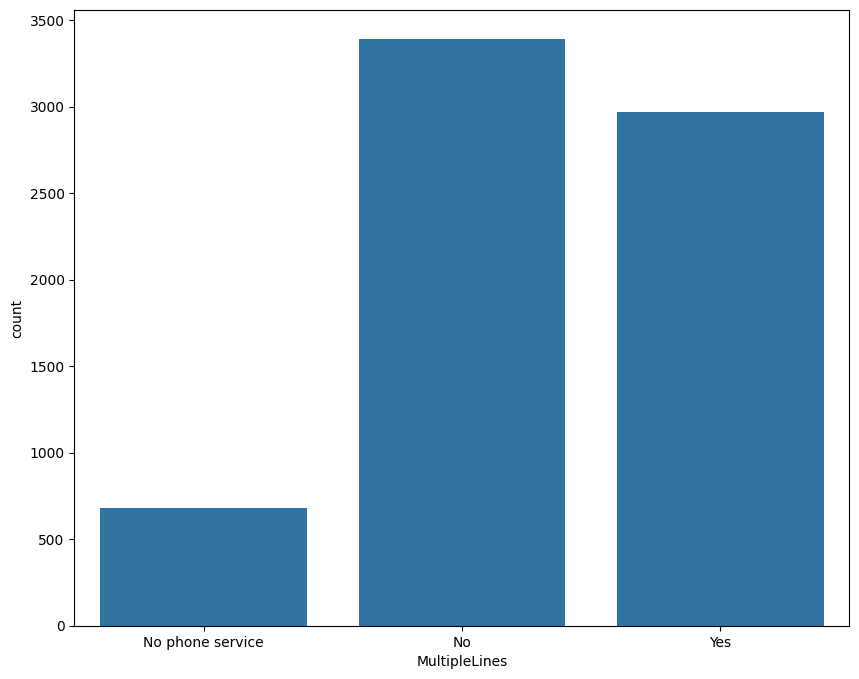

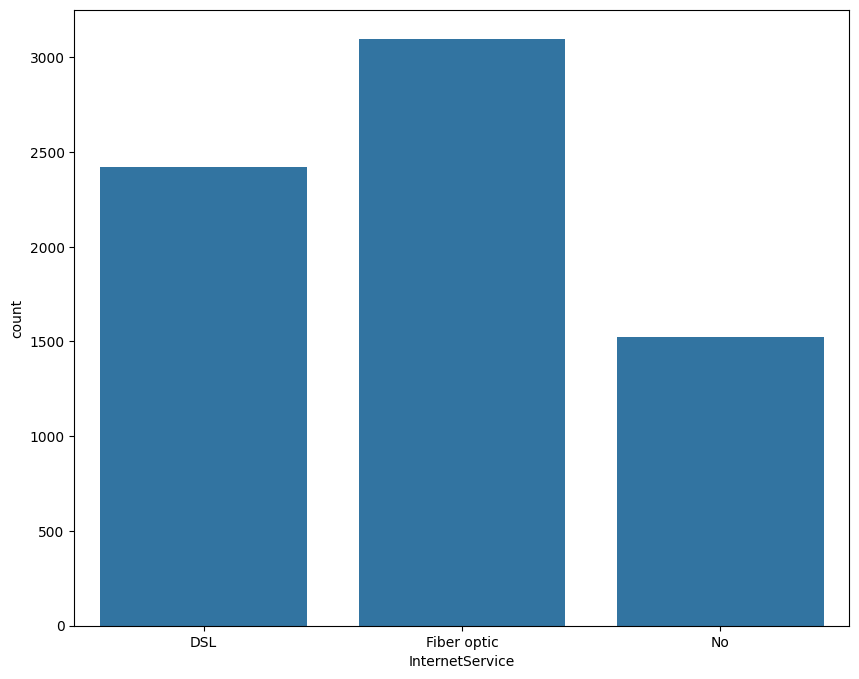

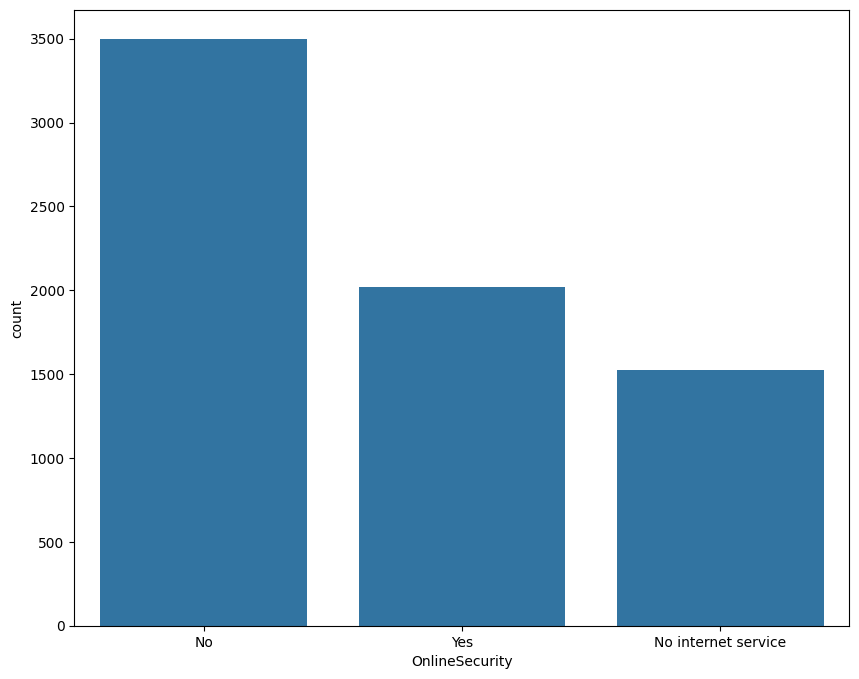

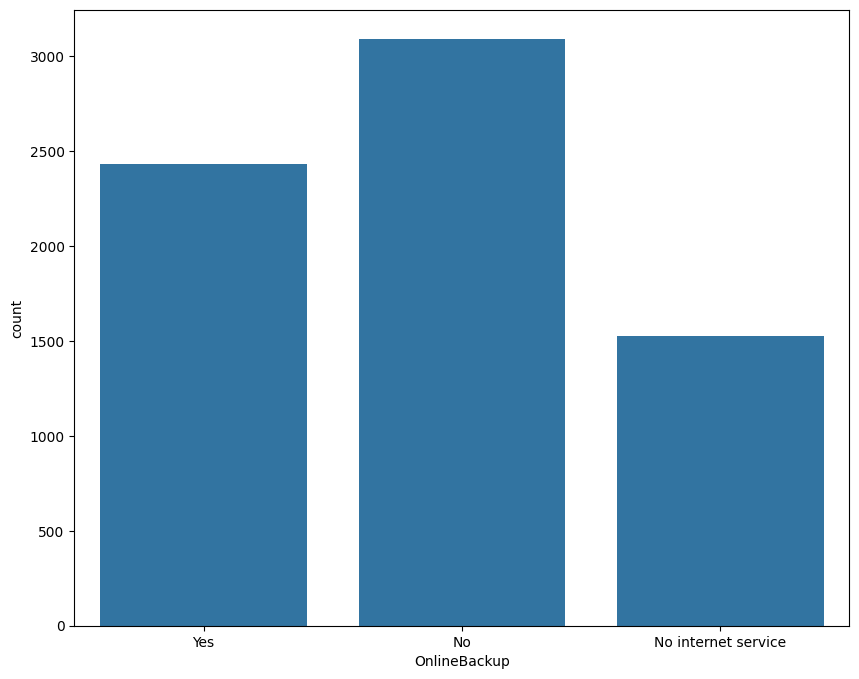

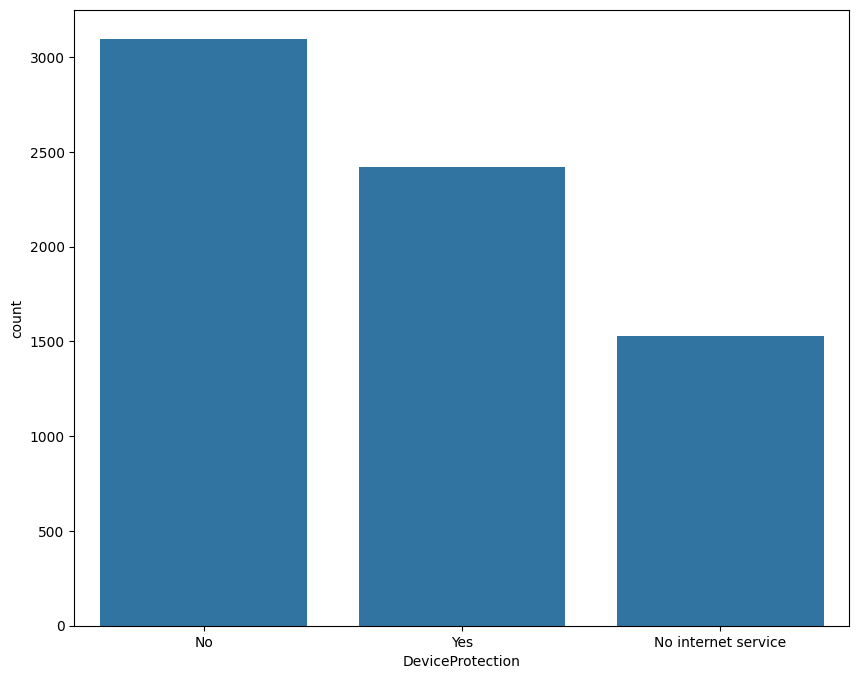

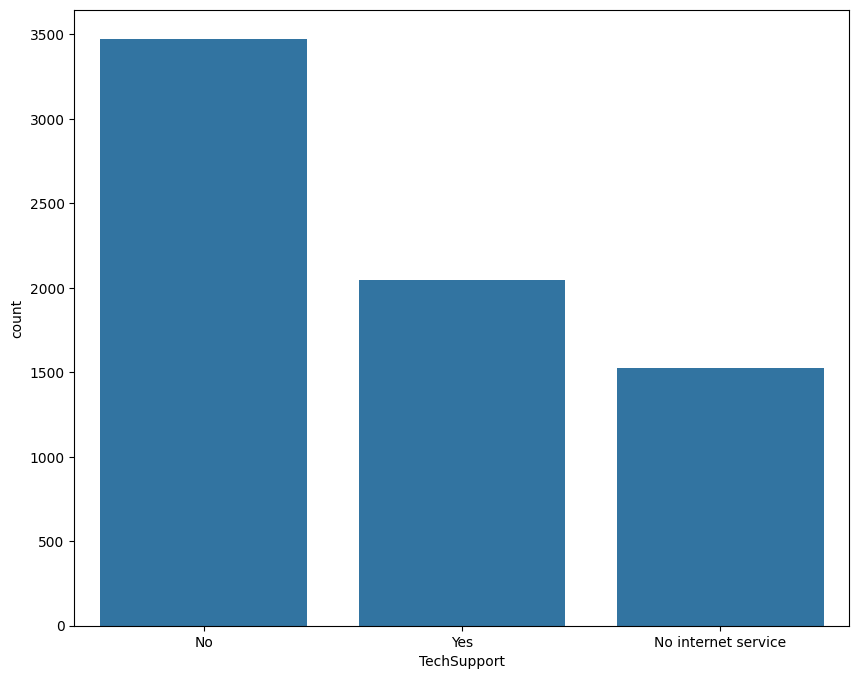

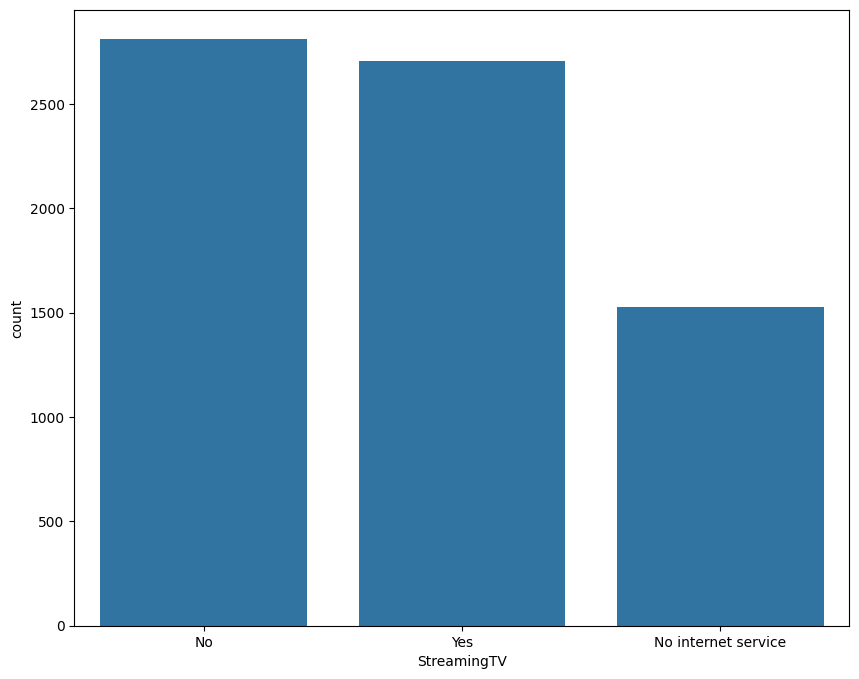

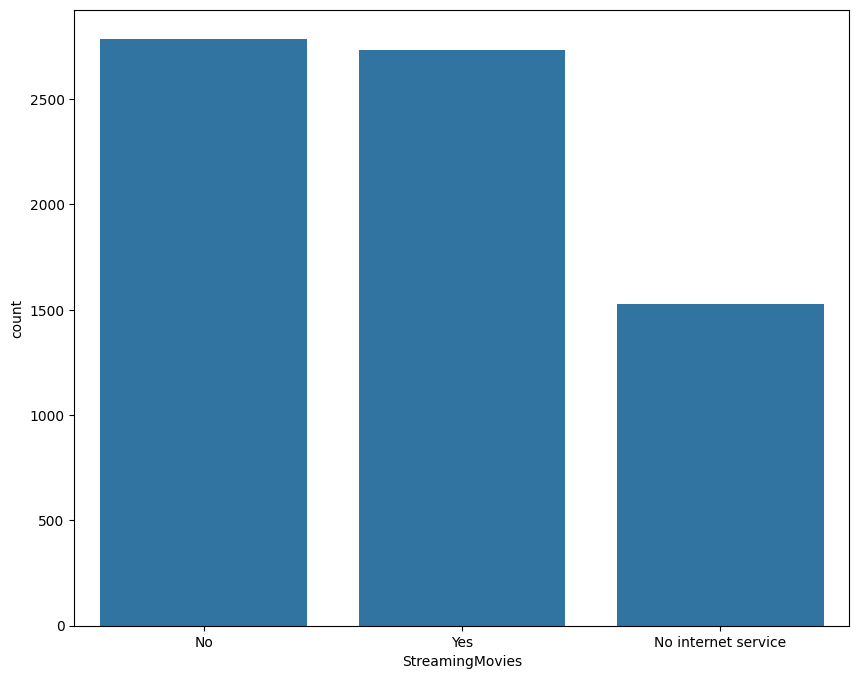

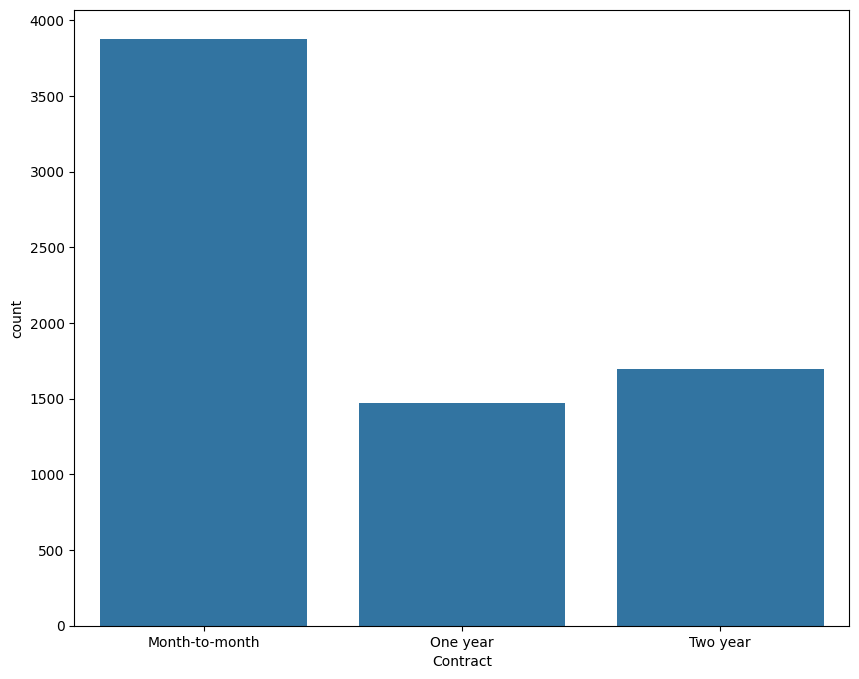

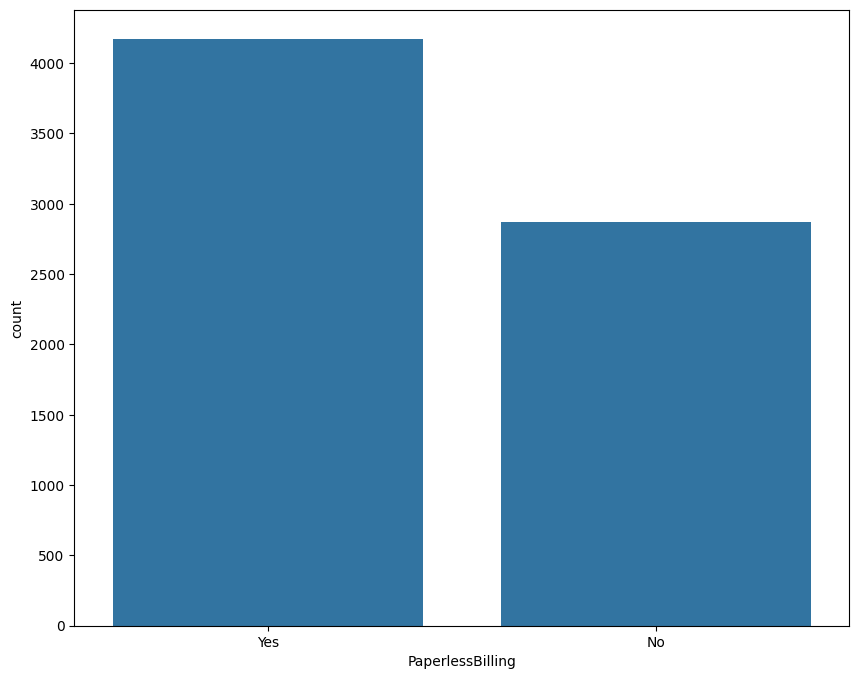

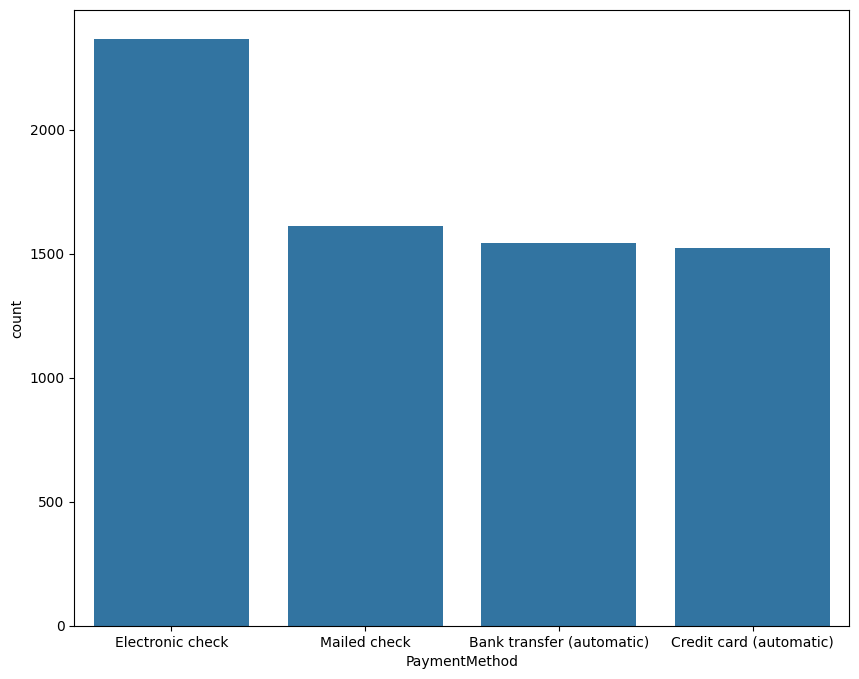

In [11]:
categorical_features = ['gender', 'SeniorCitizen','Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

for feature in categorical_features:
    display(df_churn[feature].value_counts())
    plt.figure(figsize = (10,8))
    sns.countplot(data = df_churn, x = feature)
    

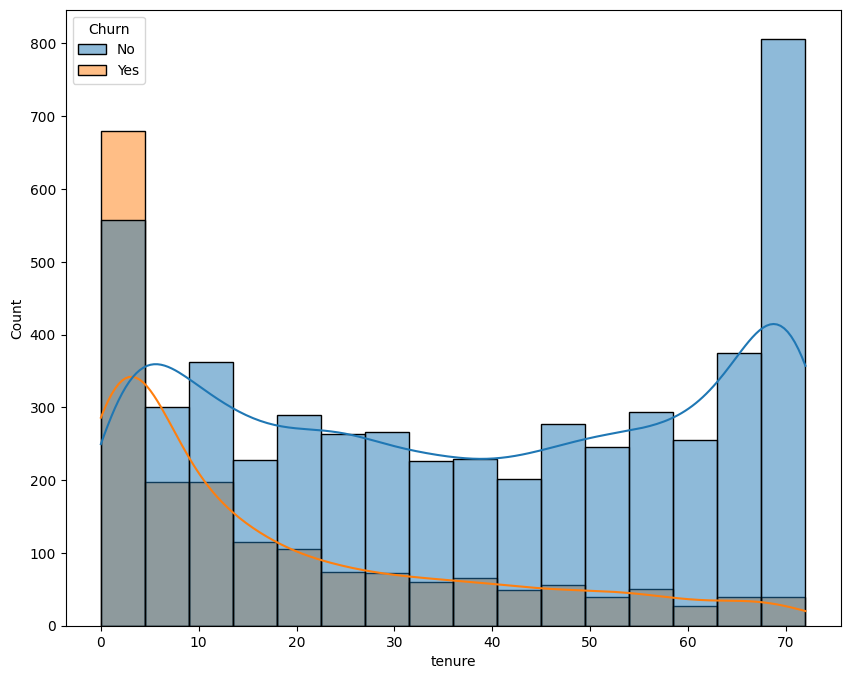

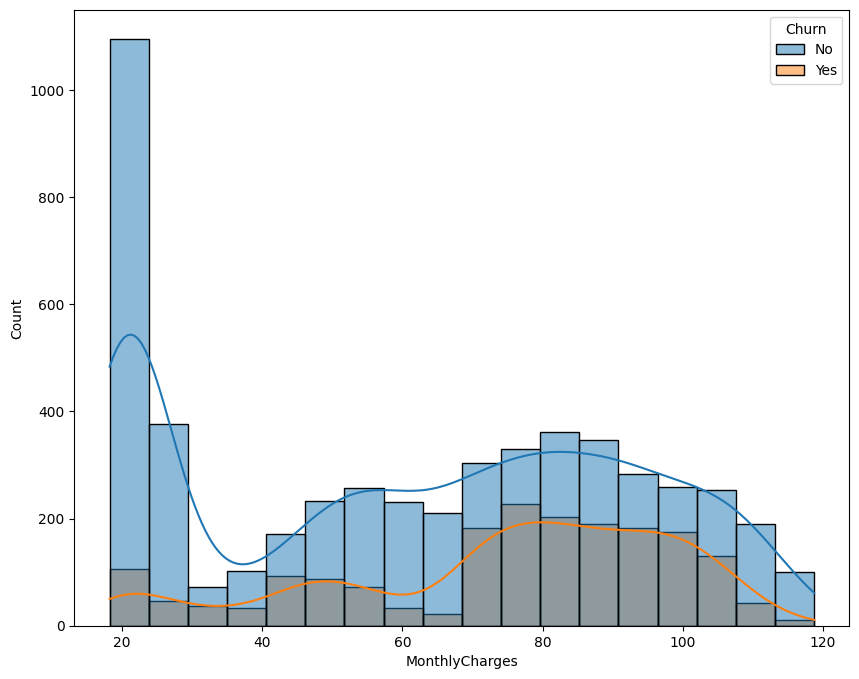

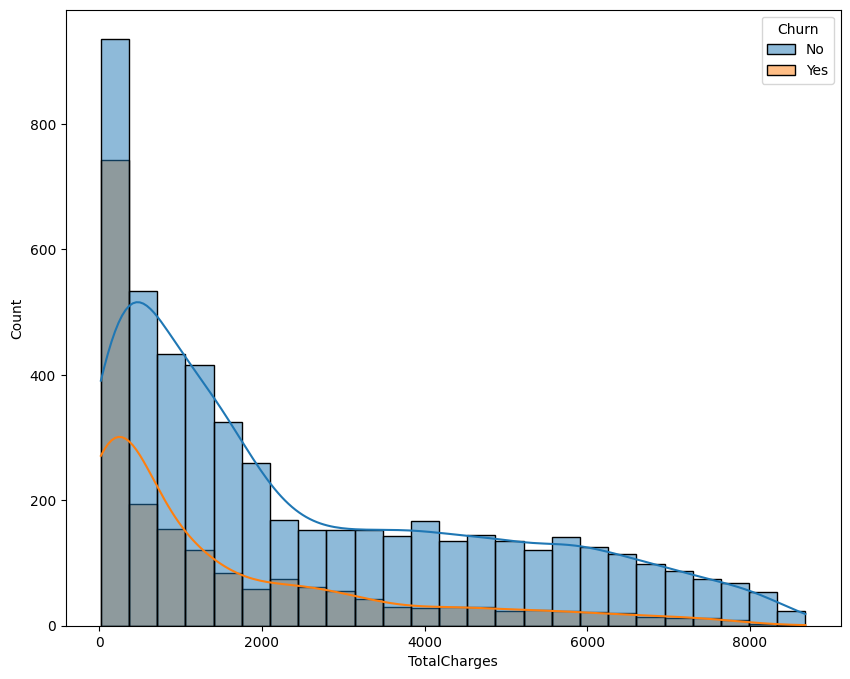

In [12]:
numerical_feature = ['tenure', 'MonthlyCharges', 'TotalCharges']
for feature in numerical_feature:
    plt.figure(figsize = (10,8))
    sns.histplot(data = df_churn, x = feature, hue = 'Churn', kde = True)

Question 12:

<Axes: xlabel='Contract', ylabel='count'>

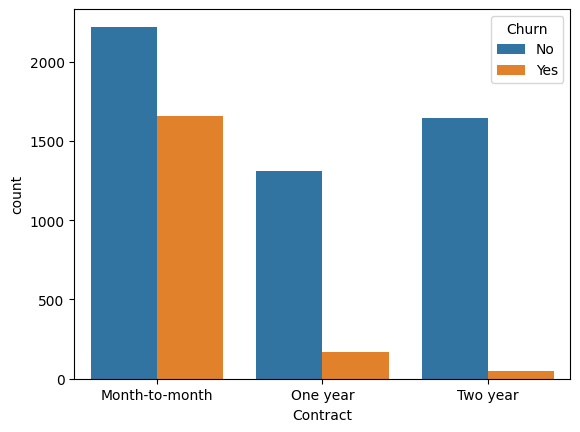

In [13]:
sns.countplot(data = df_churn, x = 'Contract', hue = 'Churn')

contract vs churn insights:

1. month to month contract has the highest churn rate

2. two year contract has the lowest churn rate

3. customers with month to month contract are more likely to churn than customers with one year or two year contract

<Axes: xlabel='tenure', ylabel='Density'>

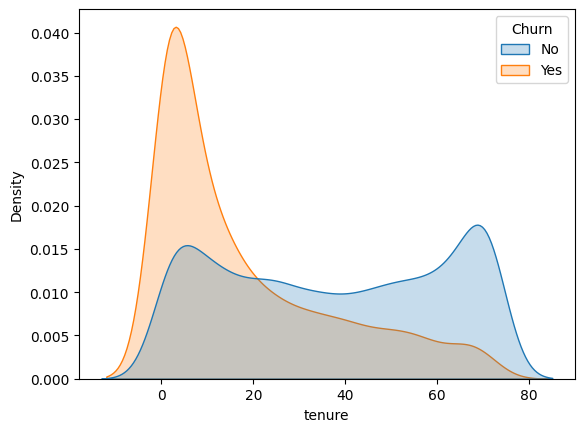

In [14]:
sns.kdeplot(data = df_churn, x = 'tenure', hue = 'Churn', fill = True, common_norm = False)

1. Customers with low tenure are more likely to churn.
This suggests that the company should focus on improving customer experience and engagement during the first few months.

2. Customers with higher tenure have lower churn rates.
This means long-term customers are more loyal, so loyalty programs and long-term contract benefits may help reduce churn further.

# Q3 Z-Scores & The Empirical Rule in the Wild

BMI is a standard scale used to measure body fat based on a person's height and weight.

BMI = weight(KG) / height(m)^2

Question 13:

According to Empirical rule 68% people will be in range of 24 to 36 with standard deviation 1.

In 18 to 42 BMI range cover almost 95% people with deviation 2.

so above 42 BMI covers 2.5% people. and below 18 covers 2.5% people with 3rd or more deviation. 

Question 14:

Removing all rows with |Z| > 3 before the train-test split creates two problems:

1. Data leakage may occur because information from the entire dataset is used before splitting the data. This can affect the fairness of model evaluation.

2. Important extreme cases may be removed. In insurance datasets, high charges are often meaningful and related to real-world high-risk customers. Removing them can reduce the model’s ability to predict expensive medical cases correctly.

Question 15:

The IQR method and Z-score method may detect different outliers because they use different calculations.

The Z-score method depends on the mean and standard deviation, so it is sensitive to extreme values and works best when the data is approximately normally distributed.

The IQR method uses quartiles and is less affected by extreme values, making it more suitable for skewed data or datasets with many outliers.

The Z-score method is preferred for normally distributed data, while the IQR method is preferred for skewed or non-normal distributions.

Question 16

In [15]:
df_insurance = pd.read_csv("F:/Jupyter_Projects/Phitron AL ML/Dataset/insurance.csv")
df_insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: xlabel='bmi', ylabel='Density'>

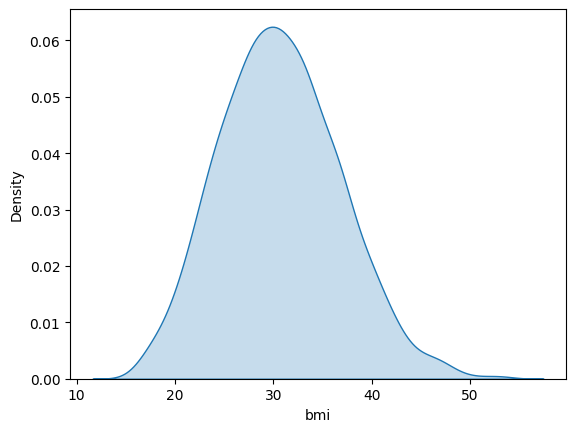

In [16]:
sns.kdeplot(data = df_insurance, x = 'bmi', fill = True)

In [17]:
skewness = df_insurance.bmi.skew()
skewness

0.2840471105987448

Question 17

In [18]:
df_insurance['charges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1338 entries, 0 to 1337
Series name: charges
Non-Null Count  Dtype  
--------------  -----  
1338 non-null   float64
dtypes: float64(1)
memory usage: 10.6 KB


In [19]:
df_insurance['charges'].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

<Axes: xlabel='charges', ylabel='Density'>

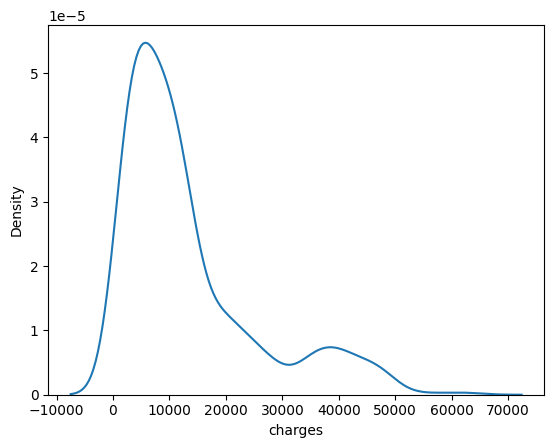

In [20]:
sns.kdeplot(x  = df_insurance['charges'])

In [21]:
q1 = df_insurance['charges'].quantile(0.25)
q3 = df_insurance['charges'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 = 1.5*iqr
outliers = df_insurance[(df_insurance['charges'] < lower_bound) | (df_insurance['charges'] > upper_bound)]
outliers

,age,sex,bmi,children,smoker,region,charges
3,33,male,22.705,0,no,northwest,21984.47061
9,60,female,25.840,0,no,northwest,28923.13692
11,62,female,26.290,0,yes,southeast,27808.72510
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
...,...,...,...,...,...,...,...
1318,35,male,39.710,4,no,northeast,19496.71917
1321,62,male,26.695,0,yes,northeast,28101.33305
1323,42,female,40.370,2,yes,southeast,43896.37630
1328,23,female,24.225,2,no,northeast,22395.74424


In [22]:

mean = df_insurance['charges'].mean()
std = df_insurance['charges'].std()
df_insurance['z_score'] = (df_insurance['charges'] - mean) / std
outliers_z = df_insurance[(df_insurance['z_score'] < -3) | (df_insurance['z_score'] > 3)]
outliers_z

,age,sex,bmi,children,smoker,region,charges,z_score
34,28,male,36.400,1,yes,southwest,51194.55914,3.131635
543,54,female,47.410,0,yes,southeast,63770.42801,4.170104
577,31,female,38.095,1,yes,northeast,58571.07448,3.740761
819,33,female,35.530,0,yes,northwest,55135.40209,3.457055
1146,60,male,32.800,0,yes,southwest,52590.82939,3.246934
1230,52,male,34.485,3,yes,northwest,60021.39897,3.860523
1300,45,male,30.360,0,yes,southeast,62592.87309,4.072866


Using the IQR method, 317 outliers were detected in the charges column.

Using the Z-score method with threshold |Z| > 3, only 7 outliers were detected.

The IQR method detected many more outliers than the Z-score method. This happened because the charges column is highly skewed and contains extreme values. The Z-score method depends on the mean and standard deviation, so it becomes less sensitive when the data is not normally distributed. So it is more conservative.

In [23]:
df_insurance['bmi_category'] = pd.cut(df_insurance.bmi, bins = [0, 18.5, 24.9, 29.9, np.inf], labels = ['Underweight', 'Normal weight', 'Overweight', 'Obese'])
df_insurance.head()

,age,sex,bmi,children,smoker,region,charges,z_score,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,0.298472,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,-0.953333,Obese
2,28,male,33.000,3,no,southeast,4449.46200,-0.728402,Obese
3,33,male,22.705,0,no,northwest,21984.47061,0.719574,Normal weight
4,32,male,28.880,0,no,northwest,3866.85520,-0.776512,Overweight


<Axes: xlabel='bmi_category', ylabel='charges'>

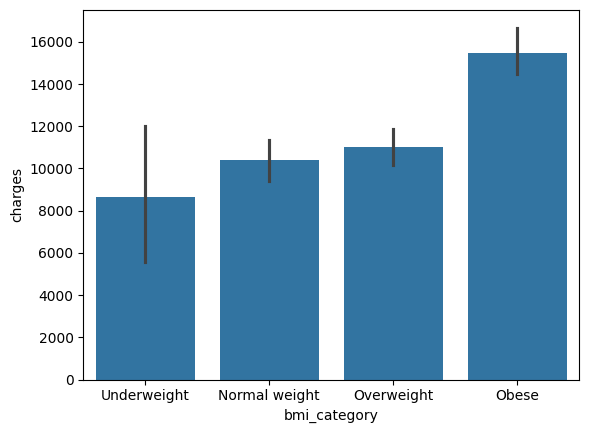

In [24]:
sns.barplot(data = df_insurance, x = 'bmi_category', y = 'charges')


pattern from barplot

Over BMI category has higher charges than normal weight and underweight category. Obese category has the highest charges among all categories. This suggests that there may be a positive correlation between BMI and insurance charges, with higher BMI categories tending to have higher charges.

# Q4 The Big City Problem

Question 19

86,400 seconds is exactly 24 hours and that's already suspicious. Real NYC taxi trips don't last 24 hours. Even the longest possible ride would be 2–3 hours max. Nobody sits in a cab for a full day.

The fact that it's exactly 84400 strongly suggests it's a default or placeholder value, not a real measurement. I'd treat it as a data entry error and remove it.

Question 20

No, we should not remove outliers from the test set.

We clean the training set so the model learns better patterns. But the test set represents the real world and in real world production, outliers will show up. If we remove them from the test set, our evaluation looks artificially good but the model will fail in deployment.

Question 21

In [25]:
df_train = pd.read_csv("F:/Jupyter_Projects/Phitron AL ML/Dataset/nyc-taxi-trip-duration/train/train.csv").sample(20000, random_state = 42).reset_index(drop = True)
df_test = pd.read_csv("F:/Jupyter_Projects/Phitron AL ML/Dataset/nyc-taxi-trip-duration/test/test.csv")
df_train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2793718,2,2016-06-08 07:36:19,2016-06-08 07:53:39,1,-73.985611,40.735943,-73.980331,40.760468,N,1040
1,id3485529,2,2016-04-03 12:58:11,2016-04-03 13:11:58,1,-73.978394,40.764351,-73.991623,40.749859,N,827
2,id1816614,2,2016-06-05 02:49:13,2016-06-05 02:59:27,5,-73.989059,40.744389,-73.973381,40.748692,N,614
3,id1050851,2,2016-05-05 17:18:27,2016-05-05 17:32:54,2,-73.990326,40.731136,-73.991264,40.748917,N,867
4,id0140657,1,2016-05-12 17:43:38,2016-05-12 19:06:25,4,-73.789497,40.646675,-73.987137,40.759232,N,4967


In [26]:
df_train['pickup_datetime'] = pd.to_datetime(df_train['pickup_datetime'])


df_train['hour']  = df_train['pickup_datetime'].dt.hour
df_train['dow']   = df_train['pickup_datetime'].dt.dayofweek
df_train['month'] = df_train['pickup_datetime'].dt.month

display((df_train['trip_duration'] <= 0).sum())
display((df_train['trip_duration'] > 86400).sum())

0

0

Question 22

In [27]:
Q1  = df_train['trip_duration'].quantile(0.25)
Q3  = df_train['trip_duration'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_train[(df_train['trip_duration'] < lower) | (df_train['trip_duration'] > upper)]

print(f"Outliers detected  : {len(outliers)}")
print(f"Percentage         : {len(outliers)/len(df_train)*100:.2f}%")


df_clean = df_train[(df_train['trip_duration'] >= lower) & (df_train['trip_duration'] <= upper)]
print(f"Rows after cleaning: {len(df_clean)}")

Outliers detected  : 959
Percentage         : 4.79%
Rows after cleaning: 19041


Question 23

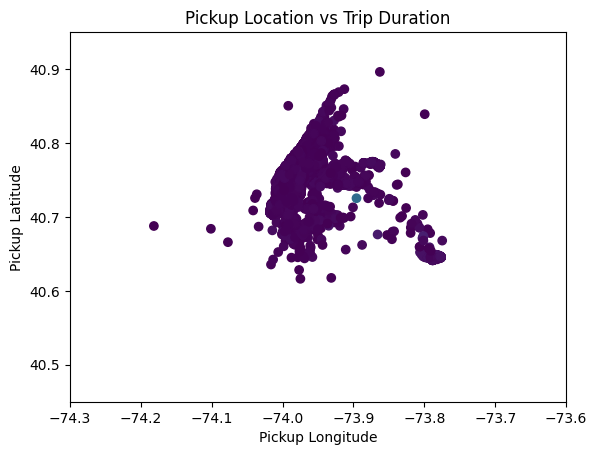

In [28]:
scatter = plt.scatter(
    df_train['pickup_longitude'],
    df_train['pickup_latitude'],
    c=df_train['trip_duration'],
)

plt.xlim(-74.3, -73.6)
plt.ylim(40.45, 40.95)
plt.xlabel('Pickup Longitude')
plt.ylabel('Pickup Latitude')
plt.title('Pickup Location vs Trip Duration')
plt.show()

# Q5 Happiness by The Numbers

Question 24

The original GDP per capita values vary greatly among countries. Some countries may have a GDP per capita around 1,500 dollars, while others may exceed 80,000 dollars. Because of these extremely large values, the distribution becomes right-skewed.

If raw GDP values are used directly, statistical models may become overly influenced by countries with very high GDP. Log transformation helps reduce this problem by compressing large values into a smaller range.

As a result, the data becomes more balanced, skewness decreases, and the distribution becomes closer to a normal distribution. This makes the analysis and modeling more reliable.


Question 25

Social support, healthy life expectancy, and freedom to make life choices are strongly related to human happiness.

If a person has supportive friends, family members, or trusted people, they can share their problems and receive emotional support. This reduces stress and loneliness, which can increase happiness. On the other hand, if a person has no social support, their happiness may decrease.

Healthy life expectancy is also directly connected to happiness. A healthy person usually faces fewer diseases, lower risks, and less stress about health problems. As a result, they can enjoy life more and feel happier compared to an unhealthy person.

Freedom to make life choices is another important factor. In real life, people usually enjoy work more when they can make their own decisions. They feel motivated and interested in what they do. However, if someone is forced to do something against their will, they may lose interest, become frustrated, and feel less happy.

Therefore, all three factors are expected to have a positive impact on a country's happiness score.


Question 26

The student’s conclusion is not completely correct because a scatterplot only shows a relationship between variables, not causation.

It would be more accurate to say that GDP and happiness have a positive relationship or positive correlation. Higher GDP may be associated with higher happiness, but it does not necessarily mean that GDP directly causes happiness.

For example, a person earning $10,000 may have a much better lifestyle than someone earning $1,000. However, the difference in lifestyle between a person earning $50,000 and another earning $60,000 may not be very large. This shows that the effect of GDP on happiness may decrease at higher income levels.

In addition, happiness does not depend only on GDP. Other factors such as social support, healthy life expectancy, and freedom to make life choices also strongly influence happiness.

Therefore, the student’s statement is incomplete because the scatterplot only suggests a positive relationship between GDP and happiness, not a direct cause-and-effect relationship.


Question 27

In [29]:
df = pd.read_csv("F:/Jupyter_Projects/Phitron AL ML/Dataset/happiness-report.csv")
df.head(2)

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868


In [30]:
sorted_df = df.sort_values(by = 'Ladder score', ascending = False)
display(sorted_df.head(10))
display(sorted_df.tail(10))

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798
5,Norway,Western Europe,7.392,0.035,7.462,7.323,11.053,0.954,73.3,0.960,0.093,0.270,2.43,1.543,1.108,0.782,0.703,0.249,0.427,2.580
6,Sweden,Western Europe,7.363,0.036,7.433,7.293,10.867,0.934,72.7,0.945,0.086,0.237,2.43,1.478,1.062,0.763,0.685,0.244,0.448,2.683
7,Luxembourg,Western Europe,7.324,0.037,7.396,7.252,11.647,0.908,72.6,0.907,-0.034,0.386,2.43,1.751,1.003,0.760,0.639,0.166,0.353,2.653
8,New Zealand,North America and ANZ,7.277,0.040,7.355,7.198,10.643,0.948,73.4,0.929,0.134,0.242,2.43,1.400,1.094,0.785,0.665,0.276,0.445,2.612
9,Austria,Western Europe,7.268,0.036,7.337,7.198,10.906,0.934,73.3,0.908,0.042,0.481,2.43,1.492,1.062,0.782,0.640,0.215,0.292,2.784


,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
139,Burundi,Sub-Saharan Africa,3.775,0.107,3.985,3.565,6.635,0.490,53.400,0.626,-0.024,0.607,2.43,0.000,0.062,0.155,0.298,0.172,0.212,2.876
140,Yemen,Middle East and North Africa,3.658,0.070,3.794,3.521,7.578,0.832,57.122,0.602,-0.147,0.800,2.43,0.329,0.831,0.272,0.268,0.092,0.089,1.776
141,Tanzania,Sub-Saharan Africa,3.623,0.071,3.762,3.485,7.876,0.702,57.999,0.833,0.183,0.577,2.43,0.433,0.540,0.300,0.549,0.307,0.231,1.263
142,Haiti,Latin America and Caribbean,3.615,0.173,3.953,3.276,7.477,0.540,55.700,0.593,0.422,0.721,2.43,0.294,0.173,0.227,0.257,0.463,0.139,2.060
143,Malawi,Sub-Saharan Africa,3.600,0.092,3.781,3.419,6.958,0.537,57.948,0.780,0.038,0.729,2.43,0.113,0.168,0.298,0.484,0.213,0.134,2.190
144,Lesotho,Sub-Saharan Africa,3.512,0.120,3.748,3.276,7.926,0.787,48.700,0.715,-0.131,0.915,2.43,0.451,0.731,0.007,0.405,0.103,0.015,1.800
145,Botswana,Sub-Saharan Africa,3.467,0.074,3.611,3.322,9.782,0.784,59.269,0.824,-0.246,0.801,2.43,1.099,0.724,0.340,0.539,0.027,0.088,0.648
146,Rwanda,Sub-Saharan Africa,3.415,0.068,3.548,3.282,7.676,0.552,61.400,0.897,0.061,0.167,2.43,0.364,0.202,0.407,0.627,0.227,0.493,1.095
147,Zimbabwe,Sub-Saharan Africa,3.145,0.058,3.259,3.030,7.943,0.750,56.201,0.677,-0.047,0.821,2.43,0.457,0.649,0.243,0.359,0.157,0.075,1.205
148,Afghanistan,South Asia,2.523,0.038,2.596,2.449,7.695,0.463,52.493,0.382,-0.102,0.924,2.43,0.370,0.000,0.126,0.000,0.122,0.010,1.895


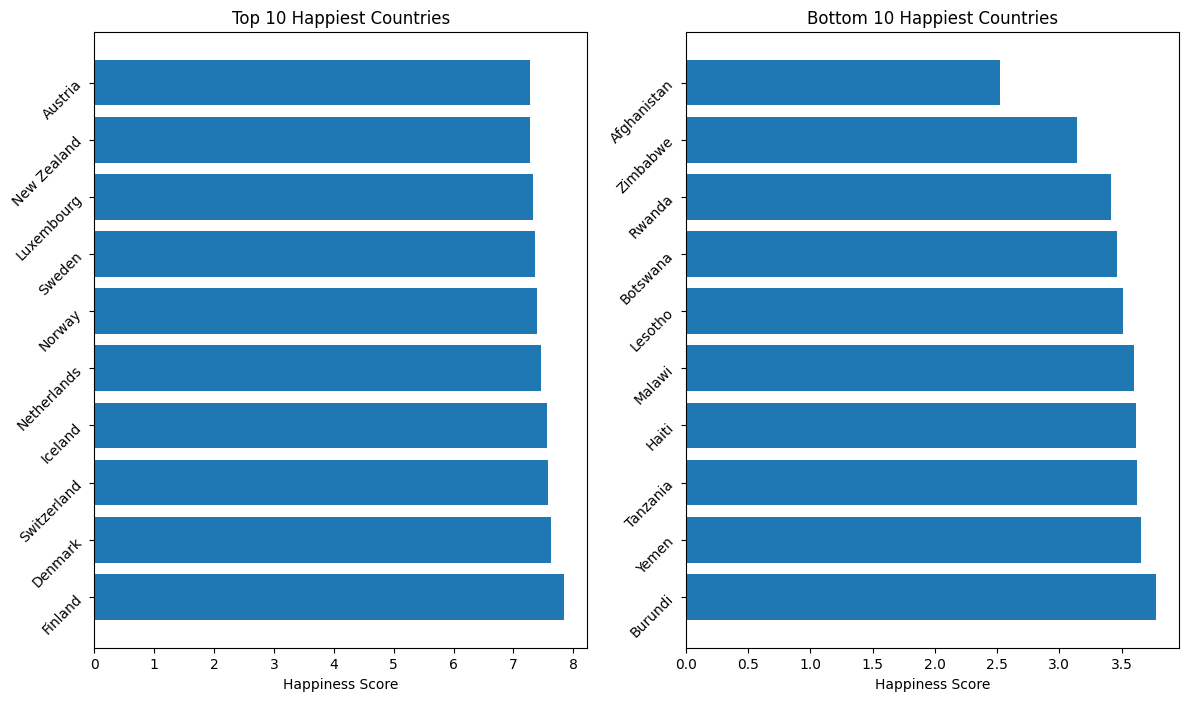

In [31]:

fig, axes = plt.subplots(1, 2, figsize=(14, 8))


axes[0].barh(sorted_df["Country name"].head(10), sorted_df["Ladder score"].head(10))
axes[0].set_title("Top 10 Happiest Countries")
axes[0].set_xlabel("Happiness Score")
axes[0].tick_params(axis='y', rotation=45)


axes[1].barh(sorted_df["Country name"].tail(10), sorted_df["Ladder score"].tail(10))
axes[1].set_title("Bottom 10 Happiest Countries")
axes[1].set_xlabel("Happiness Score")
axes[1].tick_params(axis='y', rotation=45)

plt.show()

Question 28

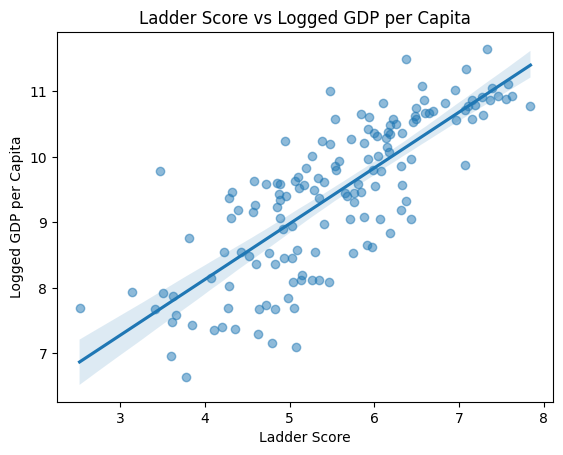

In [32]:
sns.regplot(
    data = df,
    x = 'Ladder score',
    y = 'Logged GDP per capita',
    scatter_kws={'alpha':0.5}
)

plt.title("Ladder Score vs Logged GDP per Capita")
plt.xlabel("Ladder Score")
plt.ylabel("Logged GDP per Capita")
plt.show()

Question 29

In [33]:
region_mean = df.groupby("Regional indicator").mean(numeric_only=True)

region_mean_sorted = region_mean.sort_values(by="Ladder score", ascending=False)

print(region_mean_sorted["Ladder score"])

Regional indicator
North America and ANZ                 7.128500
Western Europe                        6.914905
Central and Eastern Europe            5.984765
Latin America and Caribbean           5.908050
East Asia                             5.810333
Commonwealth of Independent States    5.467000
Southeast Asia                        5.407556
Middle East and North Africa          5.219765
Sub-Saharan Africa                    4.494472
South Asia                            4.441857
Name: Ladder score, dtype: float64


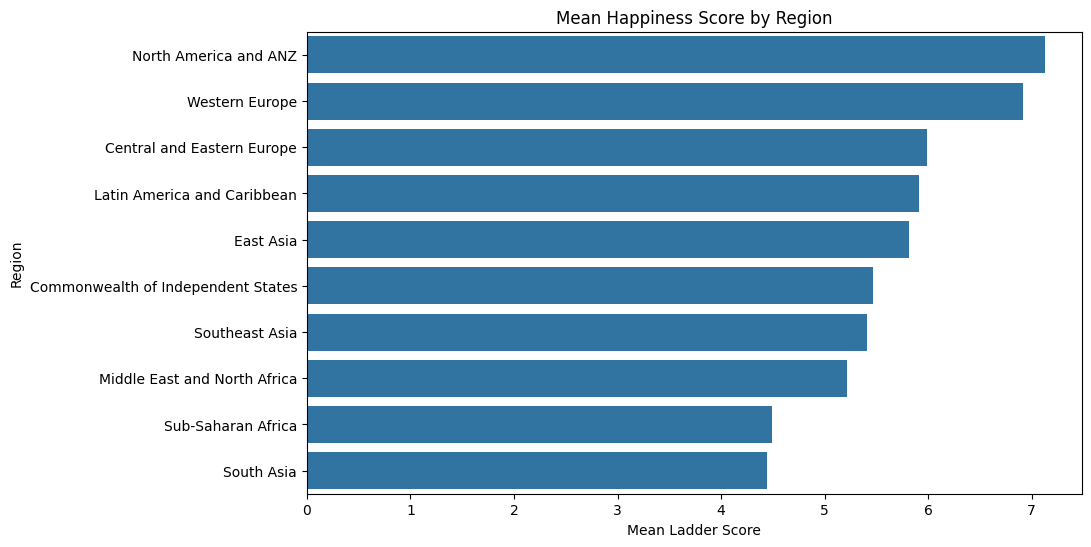

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_mean_sorted["Ladder score"],
    y=region_mean_sorted.index
)

plt.title("Mean Happiness Score by Region")
plt.xlabel("Mean Ladder Score")
plt.ylabel("Region")

plt.show()

In [35]:
region_variance = df.groupby("Regional indicator")["Ladder score"].var()

region_variance_sorted = region_variance.sort_values(ascending=False)

print(region_variance_sorted)

Regional indicator
Middle East and North Africa          0.998519
South Asia                            0.986966
Latin America and Caribbean           0.480896
Western Europe                        0.431018
Sub-Saharan Africa                    0.428884
Southeast Asia                        0.367565
Central and Eastern Europe            0.243370
East Asia                             0.193524
Commonwealth of Independent States    0.191946
North America and ANZ                 0.019060
Name: Ladder score, dtype: float64


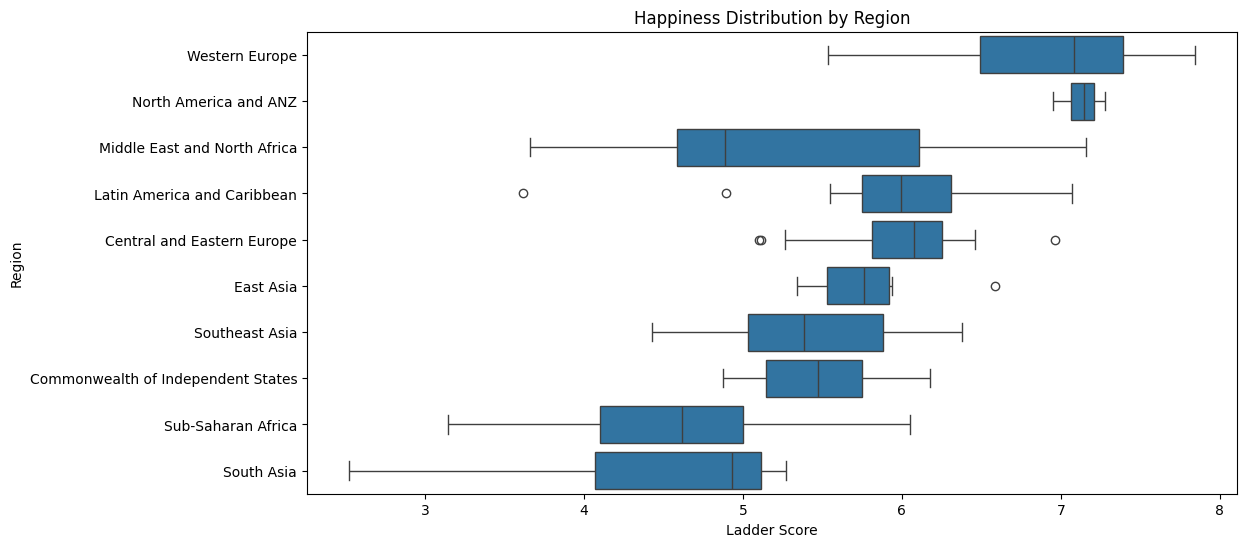

In [36]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Ladder score",
    y="Regional indicator"
)

plt.title("Happiness Distribution by Region")
plt.xlabel("Ladder Score")
plt.ylabel("Region")

plt.show()